<a href="https://colab.research.google.com/github/Katerinachristopoulou/Data_mining/blob/main/%CE%91%CE%BD%CF%84%CE%AF%CE%B3%CF%81%CE%B1%CF%86%CE%BF_coursework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── 1.  LOAD DATASET ────────────────────────────────────────────────────────
#load dataset
import pandas as pd
df=pd.read_csv("StudentsPerformance.csv.xls")
print("Display the first 5 rows of the dataset")
print(df.head())
#verify dataset existance
if df is not None and len(df)>0:
  print("Dataset printed sucessfully!")
#check for missing values
print("Missing values per column")
missing = df.isnull().sum()
print(missing)
total_missing=int(missing.sum())
print(f"\nTotal missing values: {total_missing}")
#remove them
if total_missing>0:
  df=df.dropna()
  print("\n missing values have been sucessfully removed")
#print dataset size
print(f"\n the data set size is :({df.shape[0]},{df.shape[1]})")
cells= (df.shape[0]) *(df.shape[1])

Display the first 5 rows of the dataset
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
Dataset printed sucessfully!
Missing values per column
gender                         0
race/ethnicity                 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1.  PREPARE SCORES ────────────────────────────────────────────────────────


df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

def classify(score):
    if score >= 85:   return 'A'
    elif score >= 65: return 'B'
    elif score >= 50: return 'C'
    else:             return 'Fail'

df['grade'] = df['average_score'].apply(classify)

X = pd.get_dummies(df.drop(columns=['average_score', 'grade']))
y = df['grade']

# ── 2. GRID SEARCH: ALL SPLIT × DEPTH COMBOS ─────────────────────────────────

print("=" * 72)
print("  Decision Tree — Entropy Criterion | Split × Depth Search")
print("=" * 72)
print(f"{'Split':>8} {'Depth':>6} {'Train':>8} {'Test':>8} {'F1':>8} {'Gap':>8}")
print("-" * 72)

results = []
test_sizes = [0.40, 0.30, 0.20, 0.15, 0.10]

for test_size in test_sizes:
    split_label = f"{int((1-test_size)*100)}/{int(test_size*100)}"
    for depth in range(3, 11):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=42,
            stratify=y
        )
        model = DecisionTreeClassifier(
            max_depth=depth,
            criterion='entropy',
            random_state=42
        )
        model.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc  = accuracy_score(y_test,  model.predict(X_test))
        test_f1   = f1_score(y_test, model.predict(X_test), average='weighted')
        gap       = train_acc - test_acc

        results.append({
            'split':      split_label,
            'test_size':  test_size,
            'depth':      depth,
            'train_acc':  round(train_acc, 4),
            'test_acc':   round(test_acc,  4),
            'f1':         round(test_f1,   4),
            'gap':        round(gap,       4)
        })

        print(f"{split_label:>8} {depth:>6} {train_acc:>8.4f} {test_acc:>8.4f} "
              f"{test_f1:>8.4f} {gap:>8.4f}")

    print("-" * 72)

# ── 3. FIND BEST COMBO ────────────────────────────────────────────────────────

results_df = pd.DataFrame(results)

# Score = F1 - gap: rewards high accuracy AND low overfitting
results_df['score'] = results_df['f1'] - results_df['gap']
best = results_df.loc[results_df['score'].idxmax()]

best_split     = best['split']
best_test_size = best['test_size']
best_depth     = int(best['depth'])

print("\n" + "=" * 72)
print("  TOP 5 COMBINATIONS  (ranked by F1 − gap)")
print("=" * 72)
top5 = results_df.sort_values('score', ascending=False).head(5)
print(f"{'Rank':>5} {'Split':>8} {'Depth':>6} {'F1':>8} {'Gap':>8} {'Score':>8}")
print("-" * 72)
for rank, (_, row) in enumerate(top5.iterrows(), 1):
    marker = "  <-- BEST" if rank == 1 else ""
    print(f"{rank:>5} {row['split']:>8} {int(row['depth']):>6} "
          f"{row['f1']:>8.4f} {row['gap']:>8.4f} {row['score']:>8.4f}{marker}")

print("\n" + "=" * 72)
print(f"  OPTIMAL COMBO: Split = {best_split}  |  max_depth = {best_depth}")
print(f"  Criterion: entropy  |  F1 = {best['f1']:.4f}  |  Gap = {best['gap']:.4f}")
print("=" * 72)

# ── 4. USER MANUALLY CHOOSES SPLIT ───────────────────────────────────────────

valid_splits = {'60/40': 0.40, '70/30': 0.30, '80/20': 0.20, '85/15': 0.15, '90/10': 0.10}

print("\n" + "=" * 72)
print("  MANUAL SELECTION — Enter your preferred train/test split")
print("=" * 72)
print(f"  (Suggested by grid search: split={best_split}, depth={best_depth})")
print(f"  Available splits: 60/40  70/30  80/20  85/15  90/10\n")

while True:
    chosen_split = input("  Enter your chosen split (e.g. 80/20): ").strip()
    if chosen_split in valid_splits:
        chosen_test_size = valid_splits[chosen_split]
        break
    print("  Invalid split. Choose from: 60/40  70/30  80/20  85/15  90/10")

# ── 5. BUILD & TRAIN FINAL MODEL ─────────────────────────────────────────────

# Pick the best depth for the user's chosen split from the grid search results
split_rows = results_df[results_df['split'] == chosen_split].copy()
split_rows['score'] = split_rows['f1'] - split_rows['gap']
chosen_depth = int(split_rows.loc[split_rows['score'].idxmax(), 'depth'])

print("\n" + "=" * 72)
print(f"  Training with: split={chosen_split}  |  depth={chosen_depth}  |  criterion=entropy")
print("=" * 72)

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X, y,
    test_size=chosen_test_size,
    random_state=42,
    stratify=y
)

print(f"\n  Train size : {len(X_train_final)} samples")
print(f"  Test size  : {len(X_test_final)} samples")
print(f"\n  Train class distribution:\n{y_train_final.value_counts().to_string()}")
print(f"\n  Test class distribution:\n{y_test_final.value_counts().to_string()}")

final_model = DecisionTreeClassifier(
    max_depth=chosen_depth,
    criterion='entropy',
    random_state=42
)
final_model.fit(X_train_final, y_train_final)
print("\n  Model trained successfully.")

# Create dataframes for saving
train_df = pd.concat([X_train_final, y_train_final], axis=1)
test_df = pd.concat([X_test_final, y_test_final], axis=1)

# Save results as CSV files
train_df.to_csv("train_stratified.csv", index=False)
test_df.to_csv("test_stratified.csv", index=False)

print("Stratified datasets created successfully.")
print("Training set size:", train_df.shape)
print("Test set size:", test_df.shape)

# Display class distribution
print("\nTraining set class distribution:")
print(train_df['grade'].value_counts())

print("\nTest set class distribution:")
print(test_df['grade'].value_counts())

# ── 6. EVALUATE ON TEST SET ───────────────────────────────────────────────────

y_pred        = final_model.predict(X_test_final)
train_acc     = accuracy_score(y_train_final, final_model.predict(X_train_final))
test_acc      = accuracy_score(y_test_final,  y_pred)
test_f1       = f1_score(y_test_final, y_pred, average='weighted')
overfit_gap   = train_acc - test_acc

print("\n" + "=" * 72)
print("  CLASSIFICATION REPORT — Test Set")
print("=" * 72)
print(classification_report(y_test_final, y_pred, digits=4))


print("=" * 72)
print("  FINAL SUMMARY")
print("=" * 72)
print(f"  Chosen split       : {chosen_split}")
print(f"  Train size         : {len(X_train_final)}  |  Test size : {len(X_test_final)}")
print(f"  max_depth          : {chosen_depth}")
print(f"  Criterion          : entropy")
print(f"  Train accuracy     : {train_acc:.4f}")
print(f"  Test accuracy      : {test_acc:.4f}")
print(f"  Test F1 (weighted) : {test_f1:.4f}")
print(f"  Overfit gap        : {overfit_gap:.4f}")
print("=" * 72)

  Decision Tree — Entropy Criterion | Split × Depth Search
   Split  Depth    Train     Test       F1      Gap
------------------------------------------------------------------------
   60/40      3   0.9050   0.8275   0.8229   0.0775
   60/40      4   0.9467   0.8675   0.8655   0.0792
   60/40      5   0.9800   0.9175   0.9170   0.0625
   60/40      6   0.9883   0.9200   0.9199   0.0683
   60/40      7   0.9983   0.9125   0.9124   0.0858
   60/40      8   1.0000   0.9175   0.9173   0.0825
   60/40      9   1.0000   0.9175   0.9173   0.0825
   60/40     10   1.0000   0.9175   0.9173   0.0825
------------------------------------------------------------------------
   70/30      3   0.8786   0.8333   0.8328   0.0452
   70/30      4   0.9314   0.8833   0.8820   0.0481
   70/30      5   0.9743   0.9033   0.9031   0.0710
   70/30      6   0.9886   0.9133   0.9132   0.0752
   70/30      7   0.9943   0.9100   0.9100   0.0843
   70/30      8   0.9971   0.9133   0.9134   0.0838
   70/30      9

In [ ]:
import matplotlib.patches as mpatches
import time
from itertools import groupby
from collections import Counter

# ── 1. MAP-REDUCE SETUP ───────────────────────────────────────────────────────

grades     = list(y_train_final)
n_records  = len(grades)
grade_keys = sorted(set(grades))

print("\n" + "=" * 72)
print("  MAP-REDUCE ON TRAINING DATA")
print(f"  Input : {n_records} training records  |  Classes: {grade_keys}")
print("=" * 72)

# ── 2. MAP-REDUCE FUNCTION ────────────────────────────────────────────────────

def mapreduce(grade_list, n_workers):
    """
    MAP    : each record → (grade, 1)
    SHUFFLE: sort all pairs by key
    GROUP  : collect values under each key
    REDUCE : sum values per key → final count
    """
    n    = len(grade_list)
    base = n // n_workers
    rem  = n %  n_workers

    # Balanced chunks — first `rem` workers get one extra record
    chunks, start = [], 0
    for i in range(n_workers):
        end = start + base + (1 if i < rem else 0)
        chunks.append(grade_list[start:end])
        start = end

    # MAP
    mapped = [(g, 1) for chunk in chunks for g in chunk]

    # SHUFFLE & SORT
    mapped.sort(key=lambda x: x[0])

    # GROUP
    grouped = {
        k: [v for _, v in grp]
        for k, grp in groupby(mapped, key=lambda x: x[0])
    }

    # REDUCE
    result = {k: sum(v) for k, v in grouped.items()}

    return result, chunks

# ── 3. TEST 1–10 WORKERS ──────────────────────────────────────────────────────

worker_stats = []

for n_workers in range(1, 11):
    t0             = time.perf_counter()
    result, chunks = mapreduce(grades, n_workers)
    elapsed_ms     = (time.perf_counter() - t0) * 1000

    chunk_sizes   = [len(c) for c in chunks]
    balance_gap   = max(chunk_sizes) - min(chunk_sizes)
    records_per_w = n_records / n_workers

    worker_stats.append({
        'workers':       n_workers,
        'chunks':        chunk_sizes,
        'balance_gap':   balance_gap,
        'records_per_w': records_per_w,
        'elapsed_ms':    round(elapsed_ms, 4),
        'result':        result,
        'is_balanced':   balance_gap == 0,
    })

    print(f"\n{'─' * 72}")
    print(f"  WORKERS = {n_workers}  |  Chunks: {chunk_sizes}  |  "
          f"Gap: {balance_gap}  |  Runtime: {elapsed_ms:.4f} ms")
    print(f"{'─' * 72}")

    print(f"\n  [MAP]  Each record → (grade, 1)")
    for wi, chunk in enumerate(chunks):
        cnt   = Counter(chunk)
        pairs = "  ".join(f"({g},1)×{cnt.get(g, 0)}" for g in grade_keys)
        print(f"    Worker {wi+1:>2} [{len(chunk):>3} records] : {pairs}")

    print(f"\n  [SHUFFLE & SORT]  All (grade,1) pairs sorted by key")
    for g in grade_keys:
        print(f"    {g:>4}  →  [ 1, 1, 1, … ]  ({result[g]} ones)")

    print(f"\n  [GROUP]  Values collected under each key")
    for g in grade_keys:
        print(f"    {g:>4}  →  sum({result[g]} ones)")

    print(f"\n  [REDUCE]  Final count per grade")
    for g in grade_keys:
        bar = '█' * (result[g] // 20)
        print(f"    {g:>4}  :  {result[g]:>4}  {bar}")

    total = sum(result.values())
    print(f"\n  Total : {total} / {n_records}  "
          f"{'✓' if total == n_records else '✗ MISMATCH'}")

# ── 4. METRICS TABLE ──────────────────────────────────────────────────────────

print("\n" + "=" * 72)
print("  WORKER METRICS TABLE")
print("=" * 72)
print(f"  {'W':>3}  {'Balanced':>9}  {'Gap':>5}  {'Rec/Worker':>12}  "
      f"{'Marginal drop':>15}  {'Runtime (ms)':>14}")
print("  " + "-" * 65)

for i, s in enumerate(worker_stats):
    bal  = 'YES' if s['is_balanced'] else 'no'
    marg = (worker_stats[i-1]['records_per_w'] - s['records_per_w']
            if i > 0 else s['records_per_w'])
    print(f"  {s['workers']:>3}  {bal:>9}  {s['balance_gap']:>5}  "
          f"{s['records_per_w']:>12.1f}  {marg:>15.2f}  {s['elapsed_ms']:>14.4f}")

# ── 5. ELBOW — SUGGESTED OPTIMAL (informational) ─────────────────────────────

balanced_stats = [s for s in worker_stats if s['is_balanced']]
suggested      = balanced_stats[0]

for i in range(len(balanced_stats) - 1):
    curr       = balanced_stats[i]
    nxt        = balanced_stats[i + 1]
    drop_ratio = (curr['records_per_w'] - nxt['records_per_w']) / curr['records_per_w']
    if drop_ratio >= 0.30:
        suggested = nxt
    else:
        break

SUGGESTED = suggested['workers']

print(f"\n  Balanced configs : {[s['workers'] for s in balanced_stats]}")
print(f"  Elbow suggestion : {SUGGESTED} workers  "
      f"(balanced, last point before diminishing returns)")
print("=" * 72)

# ── 6. USER MANUALLY ENTERS NUMBER OF WORKERS ────────────────────────────────

print(f"\n  Review the metrics table above and choose your number of workers.")
print(f"  (Elbow suggestion: {SUGGESTED} workers)\n")

while True:
    try:
        chosen_workers = int(input("  Enter number of workers (1–10): ").strip())
        if 1 <= chosen_workers <= 10:
            break
        print("  Please enter a number between 1 and 10.")
    except ValueError:
        print("  Invalid input. Please enter a whole number.")

chosen_stat = next(s for s in worker_stats if s['workers'] == chosen_workers)

print()
if not chosen_stat['is_balanced']:
    print(f"  Note: {chosen_workers} workers is unbalanced "
          f"(chunk gap = {chosen_stat['balance_gap']} record).")
else:
    print(f"  {chosen_workers} workers — perfectly balanced.")

# ── 7. PLOT ───────────────────────────────────────────────────────────────────

w_range  = [s['workers']       for s in worker_stats]
gaps     = [s['balance_gap']   for s in worker_stats]
rpw_vals = [s['records_per_w'] for s in worker_stats]
is_bal   = [s['is_balanced']   for s in worker_stats]
bal_ws   = [s['workers']       for s in balanced_stats]
bal_rpws = [s['records_per_w'] for s in balanced_stats]

green_p  = mpatches.Patch(color='#16A34A', label='Balanced (gap=0)')
red_p    = mpatches.Patch(color='#E24B4A', label='Unbalanced (gap>0)')
sug_line = plt.Line2D([0], [0], color='#D97706', linestyle=':',
                      linewidth=2, label=f'Suggested = {SUGGESTED}')
cho_line = plt.Line2D([0], [0], color='#7C3AED', linestyle='--',
                      linewidth=2, label=f'Chosen = {chosen_workers}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f'Map-Reduce Worker Analysis — {n_records} Training Records  '
    f'| Split: {chosen_split}  | Chosen: {chosen_workers} workers',
    fontsize=12, fontweight='bold', y=1.01
)

# Plot 1 — Records per worker
ax1 = axes[0]
ax1.plot(w_range, rpw_vals, 'o--', color='#185FA5', linewidth=2,
         markersize=7, zorder=3)
for w, rpw, bal in zip(w_range, rpw_vals, is_bal):
    ax1.plot(w, rpw, 'o', color='#16A34A' if bal else '#E24B4A',
             markersize=9, zorder=4)
ax1.axvline(x=SUGGESTED, color='#D97706', linestyle=':', linewidth=2)
ax1.axvline(x=chosen_workers, color='#7C3AED', linestyle='--', linewidth=2)
ax1.set_title('Records per worker\n(parallelism gain)', fontsize=11)
ax1.set_xlabel('Number of workers', fontsize=10)
ax1.set_ylabel('Records per worker', fontsize=10)
ax1.set_xticks(w_range)
ax1.legend(handles=[green_p, red_p, sug_line, cho_line], fontsize=9)
ax1.grid(axis='y', color='#E2E8F0', linewidth=0.5)

# Plot 2 — Balance gap
ax2 = axes[1]
bar_cols = ['#16A34A' if b else '#E24B4A' for b in is_bal]
bars2    = ax2.bar(w_range, gaps, color=bar_cols, edgecolor='white', width=0.65)
ax2.axvline(x=SUGGESTED, color='#D97706', linestyle=':', linewidth=2)
ax2.axvline(x=chosen_workers, color='#7C3AED', linestyle='--', linewidth=2)
for bar, val in zip(bars2, gaps):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.03,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('Chunk balance gap\n(max chunk − min chunk)', fontsize=11)
ax2.set_xlabel('Number of workers', fontsize=10)
ax2.set_ylabel('Record difference', fontsize=10)
ax2.set_xticks(w_range)
ax2.set_ylim(-0.3, max(gaps) + 1.5 if max(gaps) > 0 else 2)
ax2.legend(handles=[green_p, red_p, sug_line, cho_line], fontsize=9)
ax2.grid(axis='y', color='#E2E8F0', linewidth=0.5)

# Plot 3 — Elbow curve
ax3 = axes[2]
ax3.plot(bal_ws, bal_rpws, 's-', color='#185FA5', linewidth=2,
         markersize=8, label='Rec/worker (balanced only)')
ax3.fill_between(bal_ws, bal_rpws, alpha=0.08, color='#185FA5')
ax3.axvline(x=SUGGESTED, color='#D97706', linestyle=':', linewidth=2,
            label=f'Elbow = {SUGGESTED}')
if chosen_workers in bal_ws:
    ax3.axvline(x=chosen_workers, color='#7C3AED', linestyle='--', linewidth=2,
                label=f'Chosen = {chosen_workers}')
for w, rpw in zip(bal_ws, bal_rpws):
    ax3.annotate(f'{rpw:.0f}', (w, rpw),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=9)
ax3.set_title('Elbow method\n(balanced configs only)', fontsize=11)
ax3.set_xlabel('Number of workers (balanced)', fontsize=10)
ax3.set_ylabel('Records per worker', fontsize=10)
ax3.set_xticks(bal_ws)
ax3.legend(fontsize=9)
ax3.grid(axis='y', color='#E2E8F0', linewidth=0.5)

plt.tight_layout()
plt.savefig('mapreduce_analysis.png', dpi=150, bbox_inches='tight')
plt.close()
print("\n  Plot saved: mapreduce_analysis.png")

# ── 8. FINAL RESULT ──────────────────────────────────────────────────────────

final_result = chosen_stat['result']
total_check  = sum(final_result.values())

print("\n" + "=" * 72)
print(f"  FINAL MAP-REDUCE RESULT  —  {chosen_workers} workers  |  Split: {chosen_split}")
print("=" * 72)
print(f"  Training records : {n_records}  (test set of {len(y_test_final)} excluded)")
print(f"  Workers          : {chosen_workers}")
print(f"  Chunk sizes      : {chosen_stat['chunks']}")
print(f"  Balance gap      : {chosen_stat['balance_gap']}")
print(f"  Runtime          : {chosen_stat['elapsed_ms']:.4f} ms  (informational)")
print(f"\n  {'Grade':>6}  {'Count':>7}  {'%':>7}  Distribution")
print("  " + "-" * 52)
for g in grade_keys:
    cnt = final_result[g]
    pct = cnt / n_records * 100
    bar = '█' * int(pct / 2)
    print(f"  {g:>6}  {cnt:>7}  {pct:>6.1f}%  {bar}")
print(f"\n  Total : {total_check} / {n_records}  "
      f"{'✓ VERIFIED' if total_check == n_records else '✗ MISMATCH'}")
print("=" * 72)


  MAP-REDUCE ON TRAINING DATA
  Input : 600 training records  |  Classes: ['A', 'B', 'C', 'Fail']

────────────────────────────────────────────────────────────────────────
  WORKERS = 1  |  Chunks: [600]  |  Gap: 0  |  Runtime: 0.2102 ms
────────────────────────────────────────────────────────────────────────

  [MAP]  Each record → (grade, 1)
    Worker  1 [600 records] : (A,1)×70  (B,1)×291  (C,1)×177  (Fail,1)×62

  [SHUFFLE & SORT]  All (grade,1) pairs sorted by key
       A  →  [ 1, 1, 1, … ]  (70 ones)
       B  →  [ 1, 1, 1, … ]  (291 ones)
       C  →  [ 1, 1, 1, … ]  (177 ones)
    Fail  →  [ 1, 1, 1, … ]  (62 ones)

  [GROUP]  Values collected under each key
       A  →  sum(70 ones)
       B  →  sum(291 ones)
       C  →  sum(177 ones)
    Fail  →  sum(62 ones)

  [REDUCE]  Final count per grade
       A  :    70  ███
       B  :   291  ██████████████
       C  :   177  ████████
    Fail  :    62  ███

  Total : 600 / 600  ✓

────────────────────────────────────────────────

In [ ]:
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score


# ── PART 1 — MAP-REDUCE OUTPUT QUALITY ────────────────────────────────────

print("=" * 72)
print("  PART 1 — MAP-REDUCE OUTPUT QUALITY")
print("=" * 72)

chunk_sizes = [len(c) for c in chunks]
bal_gap     = max(chunk_sizes) - min(chunk_sizes)
mr_total    = sum(final_result.values())

print(f"\n  Workers      : {chosen_workers}")
print(f"  Chunk sizes  : {chunk_sizes}")
print(f"  Balance gap  : {bal_gap}  {'✓ perfectly balanced' if bal_gap == 0 else '✗ unbalanced'}")
print(f"  Total verified: {mr_total} / {n_records}  {'✓' if mr_total == n_records else '✗ MISMATCH'}")

full_counts = Counter(y)
train_counts = Counter(y_train_final)
test_counts = Counter(y_test_final)
pred_counts = Counter(y_pred)

print(f"\n  {'Grade':>6} {'Full':>6} {'Train':>7} {'MR Out':>8} "
      f"{'MR=Train':>10} {'% of Full':>11} {'Share in Train':>15}")
print("  " + "-" * 68)

for g in grade_keys:
    full  = full_counts[g]
    train = train_counts[g]
    mr    = final_result[g]
    match = '✓ 100%' if mr == train else '✗ ERROR'
    pct_full  = mr / full * 100
    pct_train = train / n_records * 100
    bar = '█' * int(pct_train / 2)
    print(f"  {g:>6} {full:>6} {train:>7} {mr:>8} {match:>10} "
          f"{pct_full:>10.1f}% {pct_train:>8.1f}%  {bar}")

print(f"\n  {'Total':>6} {len(y):>6} {n_records:>7} {mr_total:>8}  {'✓ VERIFIED':>10}")

# ──  PART 2 — DECISION TREE MODEL PERFORMANCE ───────────────────────────────

print("\n" + "=" * 72)
print("  PART 2 — DECISION TREE MODEL PERFORMANCE  (test set)")
print("=" * 72)

print(f"\n  Train accuracy : {train_acc:.4f}  ({train_acc*100:.1f}%)")
print(f"  Test  accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)")
print(f"  Test  F1       : {test_f1:.4f}  ({test_f1*100:.1f}%)")
print(f"  Overfit gap    : {overfit_gap:.4f}  ({overfit_gap*100:.1f}%)")

print(f"\n  {'Grade':>6} {'True':>6} {'Pred':>6} {'Precision':>11} "
      f"{'Recall':>8} {'F1':>8} {'Verdict':>10}")
print("  " + "-" * 60)

for g in grade_keys:
    true_n = test_counts[g]
    pred_n = pred_counts.get(g, 0)
    prec   = precision_score(y_test_final, y_pred, labels=[g], average='macro', zero_division=0)
    rec    = recall_score(y_test_final, y_pred, labels=[g], average='macro', zero_division=0)
    f1     = f1_score(y_test_final, y_pred, labels=[g], average='macro', zero_division=0)
    verdict = ('Best' if f1 == max(
                   f1_score(y_test_final, y_pred, labels=[g2], average='macro', zero_division=0)
                   for g2 in grade_keys if g2 == g
               ) else '')
    verdict = 'Weakest' if f1 < 0.80 else 'Good' if f1 < 0.90 else 'Best'
    print(f"  {g:>6} {true_n:>6} {pred_n:>6} {prec:>10.1%} "
          f"{rec:>7.1%} {f1:>7.1%}  {verdict}")

print(f"\n  {'Wtd avg':>6} {'200':>6} {'200':>6} {test_acc:>10.1%} "
      f"{test_acc:>7.1%} {test_f1:>7.1%}")

print(f"\n  Full classification report:")
print(classification_report(y_test_final, y_pred, digits=4))

# ── 7. PART 3 — HOW MAP-REDUCE EXPLAINS MODEL PERFORMANCE ────────────────────

print("=" * 72)
print("  PART 3 — HOW MAP-REDUCE EXPLAINS MODEL PERFORMANCE")
print("=" * 72)

print(f"\n  {'Grade':>6} {'MR Count':>9} {'% Train':>9} {'Model F1':>10} {'Connection'}")
print("  " + "-" * 72)

for g in grade_keys:
    mr    = final_result[g]
    pct   = mr / n_records * 100
    f1    = f1_score(y_test_final, y_pred, labels=[g], average='macro', zero_division=0)
    rec   = recall_score(y_test_final, y_pred, labels=[g], average='macro', zero_division=0)

    all_f1s = {g2: f1_score(y_test_final, y_pred, labels=[g2], average='macro', zero_division=0) for g2 in grade_keys}
    max_mr  = max(final_result.values())
    min_f1  = min(all_f1s.values())
    max_f1  = max(all_f1s.values())

    if mr == max_mr:
        note = f'Most training examples \u2192 best recall ({rec:.1%})'
    elif f1 == max_f1:
        note = f'Highest F1 \u2014 strong class boundary'
    elif f1 == min_f1:
        note = f'Fewest in MR relative to F1 \u2192 worst recall ({rec:.1%})'
    elif g == 'Fail':
        note = f'Small but cleanly separable (avg score &lt; 50)'
    else:
        note = f'Well represented \u2192 solid performance'

    print(f"  {g:>6} {mr:>9} {pct:>8.1f}% {f1:>9.1%}   {note}")

# ──  FINAL SUMMARY ──────────────────────────────────────────────────────────

print("\n" + "=" * 72)
print("  FINAL SUMMARY")
print("=" * 72)

best_g  = max(grade_keys, key=lambda g: f1_score(y_test_final, y_pred, labels=[g], average='macro', zero_division=0))
worst_g = min(grade_keys, key=lambda g: f1_score(y_test_final, y_pred, labels=[g], average='macro', zero_division=0))

print(f"""
  Map-Reduce
    Workers          : {chosen_workers}  (perfectly balanced, gap = {bal_gap})
    Training records : {n_records}  (test set of {len(y_test_final)} excluded)
    Result           : {dict(final_result)}
    Verified         : {mr_total} / {n_records}  \u2713

  Decision Tree  (criterion=entropy, max_depth={chosen_depth})
    Train accuracy   : {train_acc:.4f}
    Test  accuracy   : {test_acc:.4f}
    Test  F1         : {test_f1:.4f}
    Overfit gap      : {overfit_gap:.4f}
    Best  class      : {best_g}  (most training examples in MR: {final_result[best_g]})
    Worst class      : {worst_g}  (fewest training examples in MR: {final_result[worst_g]})\n""")
print("=" * 72)


  PART 1 — MAP-REDUCE OUTPUT QUALITY

  Workers      : 3
  Chunk sizes  : [60, 60, 60, 60, 60, 60, 60, 60, 60, 60]
  Balance gap  : 0  ✓ perfectly balanced
  Total verified: 600 / 600  ✓

   Grade   Full   Train   MR Out   MR=Train   % of Full  Share in Train
  --------------------------------------------------------------------
       A    116      70       70     ✓ 100%       60.3%     11.7%  █████
       B    485     291      291     ✓ 100%       60.0%     48.5%  ████████████████████████
       C    296     177      177     ✓ 100%       59.8%     29.5%  ██████████████
    Fail    103      62       62     ✓ 100%       60.2%     10.3%  █████

   Total   1000     600      600  ✓ VERIFIED

  PART 2 — DECISION TREE MODEL PERFORMANCE  (test set)

  Train accuracy : 0.9800  (98.0%)
  Test  accuracy : 0.9175  (91.8%)
  Test  F1       : 0.9170  (91.7%)
  Overfit gap    : 0.0625  (6.2%)

   Grade   True   Pred   Precision   Recall       F1    Verdict
  ----------------------------------------

in the user manual input 60/40 split and 3 workers were typed in order for the results of this analysis to be produced(my implementation of this problem). If another user wants to use the traditional rule of thumb (80/20) train test split , is allowed to by the code and another number of workers is suggested (4).


  CONFUSION MATRIX — Test Set


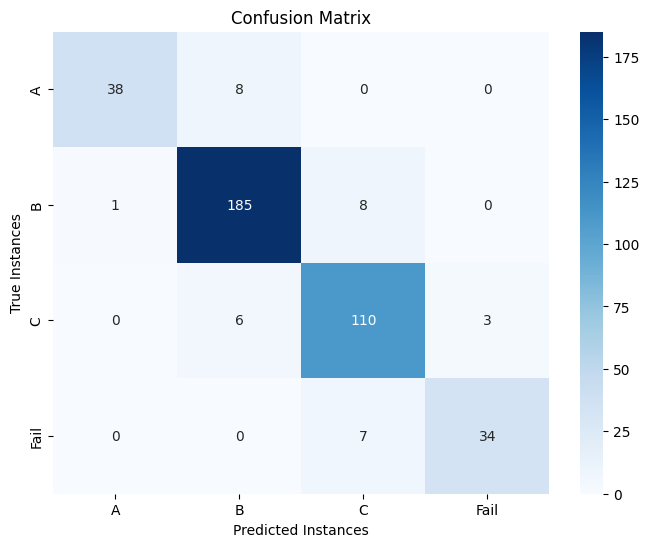

Confusion matrix saved as 'confusion_matrix.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n" + "=" * 72)
print("  CONFUSION MATRIX — Test Set")
print("=" * 72)

# Assuming y_test_final, y_pred, and final_model are available from previous cells
cm = confusion_matrix(y_test_final, y_pred, labels=final_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=final_model.classes_, yticklabels=final_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Instances')
plt.ylabel('True Instances')
plt.savefig('confusion_matrix.png', bbox_inches='tight') # Save the plot to a file
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")


  PREDICTED VS ACTUAL GRADES DISTRIBUTION — Test Set
  Grade  Count     Source
3     A     46     Actual
3     A     39  Predicted
1     B    194     Actual
1     B    199  Predicted
0     C    119     Actual
0     C    125  Predicted
2  Fail     41     Actual
2  Fail     37  Predicted


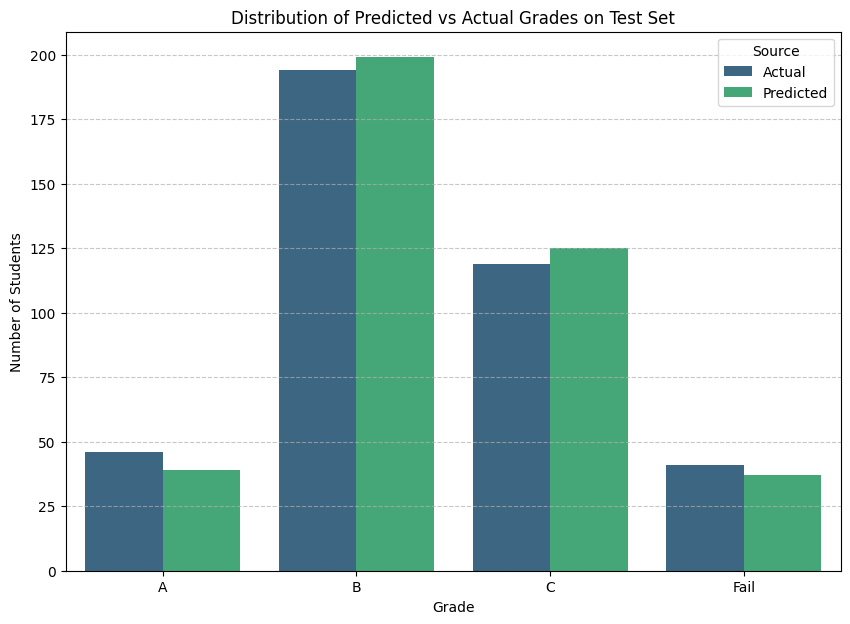

Grouped bar chart of predicted vs actual grades saved as 'predicted_vs_actual_grades_bar_chart.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Count the occurrences of each predicted grade
predicted_grade_counts = Counter(y_pred)
# Count the occurrences of each actual grade in the test set
actual_grade_counts = Counter(y_test_final)

# Convert to DataFrames and add a 'Source' column
predicted_grades_df = pd.DataFrame(predicted_grade_counts.items(), columns=['Grade', 'Count'])
predicted_grades_df['Source'] = 'Predicted'

actual_grades_df = pd.DataFrame(actual_grade_counts.items(), columns=['Grade', 'Count'])
actual_grades_df['Source'] = 'Actual'

# Combine the two DataFrames
combined_grades_df = pd.concat([predicted_grades_df, actual_grades_df])

# Ensure grade order for consistent plotting
category_order = ['A', 'B', 'C', 'Fail']
combined_grades_df['Grade'] = pd.Categorical(combined_grades_df['Grade'], categories=category_order, ordered=True)
combined_grades_df = combined_grades_df.sort_values(['Grade', 'Source'])

print("\n" + "=" * 72)
print("  PREDICTED VS ACTUAL GRADES DISTRIBUTION — Test Set")
print("=" * 72)
print(combined_grades_df)

# Create the grouped bar chart
plt.figure(figsize=(10, 7))
sns.barplot(x='Grade', y='Count', hue='Source', data=combined_grades_df, palette='viridis')
plt.title('Distribution of Predicted vs Actual Grades on Test Set')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Source')
plt.savefig('predicted_vs_actual_grades_bar_chart.png', bbox_inches='tight')
plt.show()
print("Grouped bar chart of predicted vs actual grades saved as 'predicted_vs_actual_grades_bar_chart.png'")

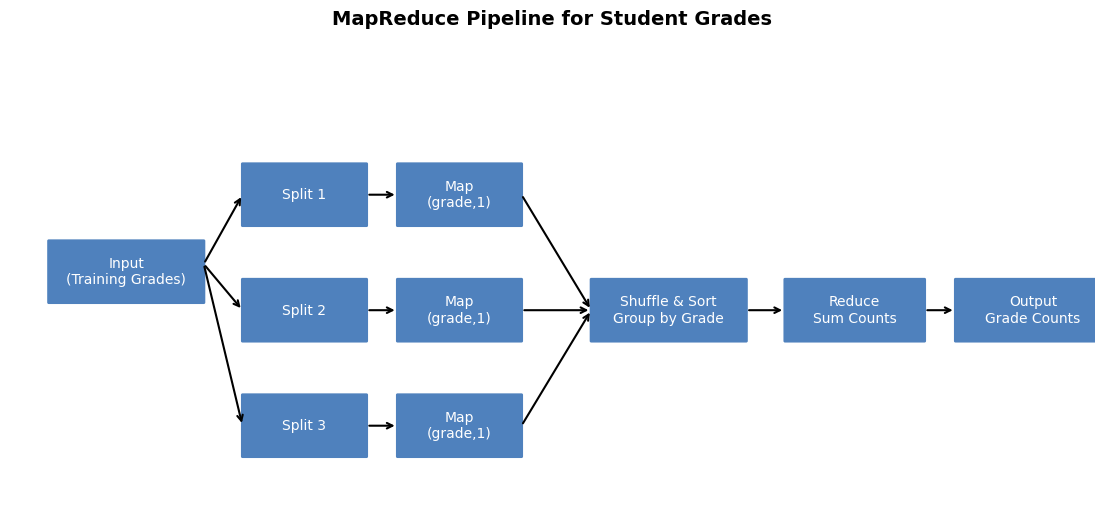

In [ ]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ── SETUP FIGURE ───────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')

# ── HELPER FUNCTION ───────────────────────────────────

def draw_box(x, y, text, width=1.6, height=0.8, color="#4F81BD"):
    box = patches.FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.02",
        edgecolor="none",
        facecolor=color
    )
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text,
            ha='center', va='center', color='white', fontsize=10)

def draw_arrow(x1, y1, x2, y2):
    ax.annotate("",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5))

# ── INPUT ───────────────────────────────────

draw_box(0.5, 2.5, "Input\n(Training Grades)", width=2)

# ── SPLITS ───────────────────────────────────

draw_box(3, 3.5, "Split 1")
draw_box(3, 2.0, "Split 2")
draw_box(3, 0.5, "Split 3")

# arrows from input
draw_arrow(2.5, 3, 3, 3.9)
draw_arrow(2.5, 3, 3, 2.4)
draw_arrow(2.5, 3, 3, 0.9)

# ── MAP ───────────────────────────────────

draw_box(5, 3.5, "Map\n(grade,1)")
draw_box(5, 2.0, "Map\n(grade,1)")
draw_box(5, 0.5, "Map\n(grade,1)")

draw_arrow(4.6, 3.9, 5, 3.9)
draw_arrow(4.6, 2.4, 5, 2.4)
draw_arrow(4.6, 0.9, 5, 0.9)

# ── SHUFFLE ───────────────────────────────────

draw_box(7.5, 2.0, "Shuffle & Sort\nGroup by Grade", width=2)

draw_arrow(6.6, 3.9, 7.5, 2.4)
draw_arrow(6.6, 2.4, 7.5, 2.4)
draw_arrow(6.6, 0.9, 7.5, 2.4)

# ── REDUCE ───────────────────────────────────

draw_box(10, 2.0, "Reduce\nSum Counts", width=1.8)

draw_arrow(9.5, 2.4, 10, 2.4)

# ── OUTPUT ───────────────────────────────────

draw_box(12.2, 2.0, "Output\nGrade Counts", width=2)

draw_arrow(11.8, 2.4, 12.2, 2.4)

# ── TITLE ───────────────────────────────────

plt.title("MapReduce Pipeline for Student Grades", fontsize=14, fontweight='bold')

# ── SAVE ───────────────────────────────────

plt.savefig("mapreduce_diagram.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
!git clone https://github.com/Katerinachristopoulou/Data_mining.git

Cloning into 'Data_mining'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
